In [2]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.visualization.wcsaxes import WCSAxes
#from wcsaxes import WCSAxes
import matplotlib.patches as patches
import matplotlib as mpl
font = {'size'   : 10}
mpl.rc('font', **font)
#minorLocator = MultipleLocator(10)

#import matplotlib.style
#mpl.style.use('classic')

#levs = np.array([-12,-5,5,12,19,26,33,40,47,54])
levs = np.arange(5.,116.,10)
rms_chan = np.array([ 0.00105744,  0.0011065 ,  0.00107581,  0.00106395,  0.00104511,
        0.00115306,  0.0013813 ,  0.00135966,  0.00165068,  0.00234356,
        0.00295551,  0.00279686,  0.00263257,  0.00274225,  0.00309272,
        0.00282996,  0.00337018,  0.00555825,  0.00955528,  0.01533015,
        0.02186677,  0.03132301,  0.0209814 ,  0.00771887,  0.02819715,
        0.02622415,  0.02021169,  0.01144515,  0.00706194,  0.0030581 ,
        0.00173754,  0.00142555,  0.00120538,  0.00116192,  0.00122801,
        0.00119458,  0.00116511,  0.00110102,  0.00110997,  0.00110746])
print(rms_chan[19:23])
#rms = (rms[17] + rms[18])/2
rms = 0.0048
print(rms)
polimin = 0
polimax = 0.012*1e3 #in mJy

vsys = 6.86 #from Su 2019; Ching 2016 used 6.7
v13=(38.525-vsys)
v14=(35.350-vsys)
v15=(32.175-vsys)
v16=(29.000-vsys)
v17=(25.825-vsys)
v18=(22.650-vsys)
v19=(19.475-vsys)
v20=(16.300-vsys)
v21=(13.125-vsys)
v22= (9.950-vsys)

xoffset=3 #4
yoffset=0
spax = 8 #pixels between pol segements
spay = 8

d0 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/red.pa18.fits")
h0 = d0[0].header
ps = h0['CDELT2']*3600 #pixel size in arcsec
ra0_deg = h0['CRVAL1']
dec0_deg = h0['CRVAL2']
fsx = 5.63 #figure size x in arcsec
fsy = 11.08 #15 #figure size y in arcsec
sx = np.round(fsx/ps) #x size
sy = np.round(fsy/ps) #y size
h0['NAXIS1'] = sx
h0['CRPIX1'] = round(sx/2)
h0['NAXIS2'] = sy
h0['CRPIX2'] = round(sy/2)
wcs = WCS(h0)
d0.close()
            
#4a1: 03 29 10.529 31 13 31.05 #from Reipurth 2002
#4a2: 03 29 10.421 31 13 32.21
ra=np.array([3,29,10.529])
dec=np.array([31,13,31.05])
dec1_deg=dec[0]+dec[1]/60+dec[2]/3600
ra1_deg=(ra[0]+ra[1]/60+ra[2]/3600)*15
dec1_pix_offset = h0['CRPIX2']+(dec1_deg-dec0_deg)*3600/ps
ra1_pix_offset = h0['CRPIX1']-(ra1_deg-ra0_deg)*3600*np.cos(dec0_deg*np.pi/180)/ps

ra=np.array([3,29,10.421])
dec=np.array([31,13,32.21])
dec2_deg=dec[0]+dec[1]/60+dec[2]/3600
ra2_deg=(ra[0]+ra[1]/60+ra[2]/3600)*15
dec2_pix_offset = h0['CRPIX2']+(dec2_deg-dec0_deg)*3600/ps
ra2_pix_offset = h0['CRPIX1']-(ra2_deg-ra0_deg)*3600*np.cos(dec0_deg*np.pi/180)/ps

#phase center 
#NGC1333IRAS4A_red	3h 29m 10.6s 31° 13' 26.5"
#NGC1333IRAS4A_blue	3h 29m 10.5s 31° 13' 35.5"
ra=np.array([3,29,10.5])
dec=np.array([31,13,35.5])
dec1_deg=dec[0]+dec[1]/60+dec[2]/3600
ra1_deg=(ra[0]+ra[1]/60+ra[2]/3600)*15
dec0_pix_offset = h0['CRPIX2']+(dec1_deg-dec0_deg)*3600/ps
ra0_pix_offset = h0['CRPIX1']-(ra1_deg-ra0_deg)*3600*np.cos(dec0_deg*np.pi/180)/ps

print(ra1_pix_offset,ra2_pix_offset,ra0_pix_offset )
print(dec1_pix_offset,dec2_pix_offset,dec0_pix_offset )

d1 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/red.i.cm.fits")
data1 = d1[0].data
data2 = data1.squeeze()
h = d1[0].header
naxis = h['NAXIS1']
d1.close() 

pix_min_y = int((naxis-sx)/2)
pix_max_y = int(naxis-pix_min_y)
pix_min_x = int((naxis-sy)/2)
pix_max_x = int(naxis-pix_min_x)

red15 = data2[15,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red16 = data2[16,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red17 = data2[17,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red18 = data2[18,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red19 = data2[19,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red20 = data2[20,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red21 = data2[21,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red22 = data2[22,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red24 = data2[24,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red25 = data2[25,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red26 = data2[26,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red27 = data2[27,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red28 = data2[28,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red29 = data2[29,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red30 = data2[30,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
red31 = data2[31,pix_min_x:pix_max_x,pix_min_y:pix_max_y]
       
##### imbin data #####
d2bin = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.i.imbin.fits")
h0bin = d2bin[0].header
data1 = d2bin[0].data
data2bin = data1.squeeze()
d2bin.close() 
iunbin_1 = np.repeat(data2bin, 8, axis=1)
iunbin = np.repeat(iunbin_1, 8, axis=2)

naxis1 = h0bin['NAXIS1']
crpix1 = h0bin['CRPIX1']
naxis2 = h0bin['NAXIS2']
crpix2 = h0bin['CRPIX2']
X_bin,Y_bin = np.meshgrid( np.arange(0,naxis1,1)-crpix1+1,np.arange(0,naxis2,1)-crpix2+1) #+1 because header count from 1, but python array count from 0
r_bin = np.sqrt(X_bin**2+Y_bin**2)*8*ps

d2bin = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.polm.fits")
data1 = d2bin[0].data
data1[data1 == 0] = 'nan' 
data1[:,r_bin > 25.3/3/2] = 'nan' 
data2bin = data1.squeeze()*1e2
d2bin.close() 
poliunbin_1 = np.repeat(data2bin, 8, axis=1)
poliunbin = np.repeat(poliunbin_1, 8, axis=2)

poli15 = poliunbin[15,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
poli16 = poliunbin[16,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
poli17 = poliunbin[17,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
poli18 = poliunbin[18,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
poli19 = poliunbin[19,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
poli20 = poliunbin[20,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
poli21 = poliunbin[21,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
poli22 = poliunbin[22,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]

poli19[red19 < levs[0]*rms] = 'nan'
poli20[red20 < levs[0]*rms] = 'nan'
poli21[red21 < levs[0]*rms] = 'nan'
poli22[red22 < levs[0]*rms] = 'nan'

d2bin = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python_2024/sn3_3_imbin_x5y3/imbin_x5y3/red.pa.fits")
data1 = d2bin[0].data
data1[data1 == 0] = 'nan' 
data1[:,r_bin > 25.3/3/2] = 'nan' 
data2bin = (data1.squeeze()+90)*np.pi/180
d2bin.close() 
paunbin_1 = np.repeat(data2bin, 8, axis=1)
paunbin = np.repeat(paunbin_1, 8, axis=2)

pa15 = paunbin[15,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
pa16 = paunbin[16,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
pa17 = paunbin[17,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
pa18 = paunbin[18,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
pa19 = paunbin[19,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
pa20 = paunbin[20,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
pa21 = paunbin[21,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]
pa22 = paunbin[22,pix_min_x-3:pix_max_x-3,pix_min_y-5:pix_max_y-5]

pa19[red19 < levs[0]*rms] = 'nan'
pa20[red20 < levs[0]*rms] = 'nan'
pa21[red21 < levs[0]*rms] = 'nan'
pa22[red22 < levs[0]*rms] = 'nan'
###########

[0.01533015 0.02186677 0.03132301 0.0209814 ]
0.0048
51.125787251277444 78.83181533279986 58.56536886577652
21.99999839975979 45.19999839982927 110.99999839974407


(222, 114) (222, 113) (222, 113)
393 507 339 561


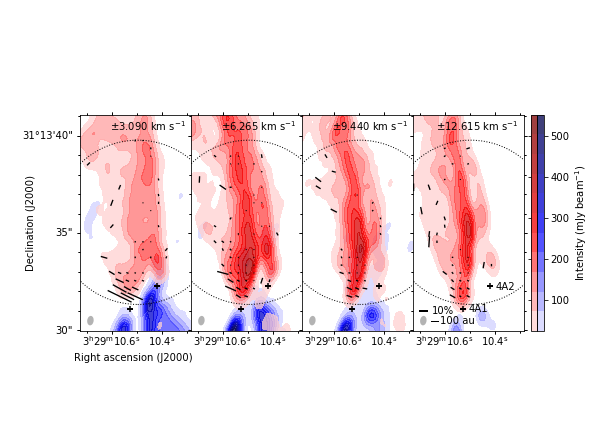

In [3]:
sc = 125 #15 #scale
wd = 0.012 #width

fig = plt.figure(figsize = (9,10))
fig.subplots_adjust(0.165,0.25,0.85,0.85,0,0)
myfontsize = 10
mylinewidth = 0.2
myalpha = 0.75
myvmax = np.amax(data2)*1.0
myvmin = -myvmax 

ax = fig.add_subplot(1,1,1,frameon=False)
ax.axes.get_yaxis().set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.set_yticklabels([])
ax.set_xticklabels([])

X,Y = np.meshgrid( np.arange(0,sx,1),np.arange(0,sy,1))
#X,Y = np.meshgrid( np.arange(0,sx,1)-0.25,np.arange(0,sy,1)+0.5 )

ax1 = fig.add_subplot(1,4,1,projection=wcs,slices=('x', 'y', 0))
lon = ax1.coords[0]
lat = ax1.coords[1]
lon.set_major_formatter('hh:mm:ss.s')
lat.set_major_formatter('dd:mm:ss')
lon.display_minor_ticks(True)
lat.display_minor_ticks(True)
#lon.set_ticklabel_visible(False)
#lat.set_ticklabel_visible(False)
lon.set_minor_frequency(2)
lat.set_minor_frequency(5)
lon.set_ticks(number=2)
lat.set_ticks(spacing=5* u.arcsec, exclude_overlapping=False)
lon.set_ticklabel(size=myfontsize)
lat.set_ticklabel(size=myfontsize)
lon.set_axislabel(' ')
lat.set_axislabel(' ')
ax1.set_aspect(1)
ax1.imshow(poli22*0, cmap='Greys',origin='lower',interpolation='nearest', vmin=polimin, vmax=polimax)
cs_blue = ax1.contourf(red24, levels=levs*rms,cmap='seismic_r',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax1.contourf(red22, levels=levs*rms,cmap='seismic',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax1.scatter(ra2_pix_offset,dec2_pix_offset,40, c='k', marker="+") 
ax1.scatter(ra1_pix_offset,dec1_pix_offset,40, c='k', marker="+") 
ax1.add_patch(patches.Ellipse((10, 10), 0.49/ps, 0.33/ps, angle=-7.9+90, linewidth=1, fc='0.7',ec='none', zorder=2))
ax1.text(0.95, 0.95, r'$\pm$'+f"{v22:.3f}"+' km s$^{-1}$', horizontalalignment='right',verticalalignment='center',transform=ax1.transAxes,fontsize=myfontsize)
ax1.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa22[xoffset::spax,yoffset::spay])*poli22[xoffset::spax,yoffset::spay], np.sin(pa22[xoffset::spax,yoffset::spay])*poli22[xoffset::spax,yoffset::spay],\
           scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='none')
#ax1.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
#           np.cos(pa22[xoffset::spax,yoffset::spay]), np.sin(pa22[xoffset::spax,yoffset::spay]),\
#           scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='none')
cbar_blue = fig.colorbar(cs_blue,cax=fig.add_axes([0.85+0.02,0.4,0.01,0.3]),ticks=np.arange(0,0.6,0.1))
cbar_blue.ax.set_yticklabels(['0','100','200','300','400','500'],size=myfontsize)
cbar_blue.set_label(r'Intensity (mJy beam$^{-1}$)',size=myfontsize)
ax1.scatter(ra0_pix_offset,dec0_pix_offset, s=26987, facecolors='none',edgecolors='k',linestyle=':')

ax2 = fig.add_subplot(1,4,2,projection=wcs,slices=('x', 'y', 0))
lon = ax2.coords[0]
lat = ax2.coords[1]
lon.set_major_formatter('hh:mm:ss.s')
lat.set_major_formatter('dd:mm:ss')
lon.display_minor_ticks(True)
lat.display_minor_ticks(True)
#lon.set_ticklabel_visible(False)
lat.set_ticklabel_visible(False)
lon.set_minor_frequency(2)
lat.set_minor_frequency(5)
lon.set_ticks(number=2)
lat.set_ticks(spacing=5* u.arcsec, exclude_overlapping=False)
lon.set_ticklabel(size=myfontsize)
lat.set_ticklabel(size=myfontsize)
lon.set_axislabel(' ')
lat.set_axislabel(' ')
ax2.set_aspect(1)
ax2.imshow(poli21*0, cmap='Greys',origin='lower',interpolation='nearest', vmin=polimin, vmax=polimax)
ax2.contourf(red25, levels=levs*rms,cmap='seismic_r',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax2.contourf(red21, levels=levs*rms,cmap='seismic',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.scatter(ra2_pix_offset,dec2_pix_offset,40, c='k', marker="+") 
ax2.scatter(ra1_pix_offset,dec1_pix_offset,40, c='k', marker="+") 
ax2.add_patch(patches.Ellipse((10, 10), 0.49/ps, 0.33/ps, angle=-7.9+90, linewidth=1, fc='0.7',ec='none', zorder=2))
ax2.text(0.95, 0.95, r'$\pm$'+f"{v21:.3f}"+' km s$^{-1}$', horizontalalignment='right',verticalalignment='center',transform=ax2.transAxes,fontsize=myfontsize)
ax2.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa21[xoffset::spax,yoffset::spay])*poli21[xoffset::spax,yoffset::spay], np.sin(pa21[xoffset::spax,yoffset::spay])*poli21[xoffset::spax,yoffset::spay],\
           scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='none')
#ax2.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
#           np.cos(pa21[xoffset::spax,yoffset::spay]), np.sin(pa21[xoffset::spax,yoffset::spay]),\
#           scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='none')
ax2.scatter(ra0_pix_offset,dec0_pix_offset, s=26987, facecolors='none',edgecolors='k',linestyle=':')

ax3 = fig.add_subplot(1,4,3,projection=wcs,slices=('x', 'y', 0))
lon = ax3.coords[0]
lat = ax3.coords[1]
lon.set_major_formatter('hh:mm:ss.s')
lat.set_major_formatter('dd:mm:ss')
lon.display_minor_ticks(True)
lat.display_minor_ticks(True)
#lon.set_ticklabel_visible(False)
lat.set_ticklabel_visible(False)
lon.set_minor_frequency(2)
lat.set_minor_frequency(5)
lon.set_ticks(number=2)
lat.set_ticks(spacing=5* u.arcsec, exclude_overlapping=False)
lon.set_ticklabel(size=myfontsize)
lat.set_ticklabel(size=myfontsize)
lon.set_axislabel(' ')
lat.set_axislabel(' ')
ax3.set_aspect(1)
ax3.imshow(poli20*0, cmap='Greys',origin='lower',interpolation='nearest', vmin=polimin, vmax=polimax)
ax3.contourf(red26, levels=levs*rms,cmap='seismic_r',alpha=myalpha, vmin=myvmin, vmax=myvmax)
cs_red = ax3.contourf(red20, levels=levs*rms,cmap='seismic',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax3.scatter(ra2_pix_offset,dec2_pix_offset,40, c='k', marker="+") 
ax3.scatter(ra1_pix_offset,dec1_pix_offset,40, c='k', marker="+") 
ax3.add_patch(patches.Ellipse((10, 10), 0.49/ps, 0.33/ps, angle=-7.9+90, linewidth=1, fc='0.7',ec='none', zorder=2))
ax3.text(0.95, 0.95, r'$\pm$'+f"{v20:.3f}"+' km s$^{-1}$', horizontalalignment='right',verticalalignment='center',transform=ax3.transAxes,fontsize=myfontsize)
ax3.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa20[xoffset::spax,yoffset::spay])*poli20[xoffset::spax,yoffset::spay], np.sin(pa20[xoffset::spax,yoffset::spay])*poli20[xoffset::spax,yoffset::spay],\
           scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='none')
#ax3.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
#           np.cos(pa20[xoffset::spax,yoffset::spay]), np.sin(pa20[xoffset::spax,yoffset::spay]),\
#           scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='none')
cbar_red = fig.colorbar(cs_red,cax=fig.add_axes([0.85+0.01,0.4,0.01,0.3]),ticks=np.arange(0,0.6,0.1))
cbar_red.ax.set_yticklabels([],size=myfontsize)
cbar_red.ax.tick_params(labelright=False, right=False, labelleft=True, left=True)
ax3.scatter(ra0_pix_offset,dec0_pix_offset, s=26987, facecolors='none',edgecolors='k',linestyle=':')

ax4 = fig.add_subplot(1,4,4,projection=wcs,slices=('x', 'y', 0))
lon = ax4.coords[0]
lat = ax4.coords[1]
lon.set_major_formatter('hh:mm:ss.s')
lat.set_major_formatter('dd:mm:ss')
lon.display_minor_ticks(True)
lat.display_minor_ticks(True)
#lon.set_ticklabel_visible(False)
lat.set_ticklabel_visible(False)
lon.set_minor_frequency(2)
lat.set_minor_frequency(5)
lon.set_ticks(number=2)
lat.set_ticks(spacing=5* u.arcsec, exclude_overlapping=False)
lon.set_ticklabel(size=myfontsize)
lat.set_ticklabel(size=myfontsize)
lon.set_axislabel(' ')
lat.set_axislabel(' ')
ax4.set_aspect(1)
ax4.imshow(poli19*0, cmap='Greys',origin='lower',interpolation='nearest', vmin=polimin, vmax=polimax)
ax4.contourf(red27, levels=levs*rms,cmap='seismic_r',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax4.contourf(red19, levels=levs*rms,cmap='seismic',alpha=myalpha, vmin=myvmin, vmax=myvmax)
ax4.scatter(ra2_pix_offset,dec2_pix_offset,40, c='k', marker="+") 
ax4.scatter(ra1_pix_offset,dec1_pix_offset,40, c='k', marker="+") 
ax4.add_patch(patches.Ellipse((10, 10), 0.49/ps, 0.33/ps, angle=-7.9+90, linewidth=1, fc='0.7',ec='none', zorder=2))
ax4.text(0.95, 0.95, r'$\pm$'+f"{v19:.3f}"+' km s$^{-1}$', horizontalalignment='right',verticalalignment='center',transform=ax4.transAxes,fontsize=myfontsize)
ax4.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
           np.cos(pa19[xoffset::spax,yoffset::spay])*poli19[xoffset::spax,yoffset::spay], np.sin(pa19[xoffset::spax,yoffset::spay])*poli19[xoffset::spax,yoffset::spay],\
           scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='none')
#ax4.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], \
#           np.cos(pa19[xoffset::spax,yoffset::spay]), np.sin(pa19[xoffset::spax,yoffset::spay]),\
#           scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='none')

ax4.quiver(10, 20, 10, 0, scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, color='k',pivot='mid',edgecolor='none')
ax4.text(30,20,'10%' ,horizontalalignment='center',verticalalignment='center',color='k',fontsize=myfontsize)
#ax4.scatter(ra0_pix_offset,dec0_pix_offset,40, c='k', marker="+")
#ax4.scatter(ra0_pix_offset,dec0_pix_offset+radius,40, c='k', marker="+") 
ax4.scatter(ra0_pix_offset,dec0_pix_offset, s=26987, facecolors='none',edgecolors='k',linestyle=':') #make sure the circle passed the two crosses from upper two lines

ax4.plot([25,25-0.3333/ps],[10,10],linewidth=1,color='k') #0.3373" = 100 AU with a distance of 300 pc ( pc from Soubiran et al. 2018)
ax4.text(45,10,'100 au' ,horizontalalignment='center',verticalalignment='center',color='k',fontsize=myfontsize)
ax4.text(ra1_pix_offset+15,dec1_pix_offset,'4A1' ,horizontalalignment='center',verticalalignment='center',color='k',fontsize=myfontsize)
ax4.text(ra2_pix_offset+15,dec2_pix_offset,'4A2' ,horizontalalignment='center',verticalalignment='center',color='k',fontsize=myfontsize)

ax.text(0.12, 0.2, r'Right ascension (J2000)',horizontalalignment='center',verticalalignment='top',transform=ax.transAxes,fontsize=myfontsize)
ax.text(-0.1, 0.5, r'Declination (J2000)',horizontalalignment='right',verticalalignment='center',
        rotation='vertical',transform=ax.transAxes,fontsize=myfontsize)

from matplotlib.patches import Circle


print(np.shape(red17),np.shape(X),np.shape(Y))
print(pix_min_y,pix_max_y,pix_min_x,pix_max_x)

plt.savefig('chapolmap_Pmag_241022.pdf')